In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
import os
 
%matplotlib inline

In [2]:
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


# create a synthetic dataset
X, y = make_blobs(random_state=0)

# split data labels into a training and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

logreg = LogisticRegression().fit(X_train, y_train)
print("Test score: ", logreg.score(X_test, y_test))

Test score:  0.88


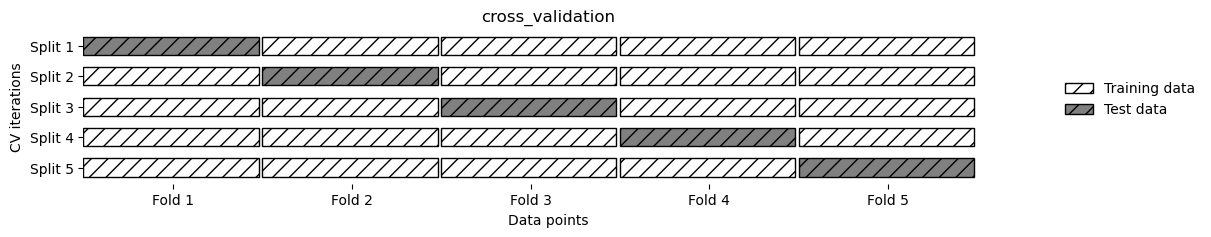

In [3]:
mglearn.plots.plot_cross_validation()

In [4]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.datasets import load_iris

iris = load_iris()
logreg = LogisticRegression(max_iter=1_000)

scores = cross_val_score(logreg, iris.data, iris.target)
print(scores)

[0.96666667 1.         0.93333333 0.96666667 1.        ]


In [5]:
print(scores.mean())

0.9733333333333334


In [6]:
scores2 = cross_validate(logreg, iris.data, iris.target, return_train_score=True)
pd.DataFrame(scores2)

,fit_time,score_time,test_score,train_score
0,0.009224,0.000286,0.966667,0.966667
1,0.009270,0.000307,1.000000,0.966667
2,0.005872,0.000268,0.933333,0.983333
3,0.007638,0.000254,0.966667,0.983333
4,0.007124,0.000189,1.000000,0.975000


In [7]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=3)

print(cross_val_score(logreg, iris.data, iris.target, cv=kfold))

[0. 0. 0.]


In [8]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5)

print(cross_val_score(logreg, iris.data, iris.target, cv=kfold))

[1.         1.         0.86666667 0.93333333 0.83333333]


In [9]:
print(iris.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [10]:
np.bincount(iris.target)

array([50, 50, 50])

In [11]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=3, shuffle=True, random_state=0)

print(cross_val_score(logreg, iris.data, iris.target, cv=kfold))

[0.98 0.96 0.96]


In [12]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()

scores = cross_val_score(logreg, iris.data, iris.target, cv=loo)
scores

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1.])

In [13]:
len(scores)

150

In [14]:
scores.mean()

np.float64(0.9666666666666667)

In [15]:
from sklearn.model_selection import ShuffleSplit

shuffle_split = ShuffleSplit(n_splits=10, train_size=.5, test_size=.5, random_state=0)
scores = cross_val_score(logreg, iris.data, iris.target, cv=shuffle_split)

In [16]:
print(scores)

[0.93333333 0.93333333 0.98666667 0.94666667 0.96       0.94666667 0.97333333
 1.         0.96       0.98666667]


In [17]:
from sklearn.model_selection import GroupKFold

X, y = make_blobs(n_samples=12, random_state=0)
groups = [0, 0, 0, 1, 1, 1, 1, 2, 2, 3, 3, 3]
scores = cross_val_score(logreg, X, y, groups=groups, cv=GroupKFold(n_splits=3))
print(scores)

[0.75       0.6        0.66666667]


In [18]:
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, random_state=0
)

print(X_train.shape, X_test.shape, sep='\n')


best_score = 0
for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)

        score = svm.score(X_test, y_test)
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

print('Best score: ', best_score)
print('Best parameters: ', best_parameters)

(112, 4)
(38, 4)
Best score:  0.9736842105263158
Best parameters:  {'C': 100, 'gamma': 0.001}


In [19]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    iris.data, iris.target, random_state=0
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, random_state=1
)

best_score = 0
for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)

        score = svm.score(X_valid, y_valid)
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

svm = SVC(**best_parameters)
svm.fit(X_trainval, y_trainval)

score = svm.score(X_test, y_test)
print(score)
print(best_parameters)
print(best_score)

0.9210526315789473
{'C': 10, 'gamma': 0.001}
0.9642857142857143


In [20]:
best_score = 0
for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        svm = SVC(gamma=gamma, C=C)
        scores = cross_val_score(svm, X_trainval, y_trainval)
        score = scores.mean()

        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

svm = SVC(**best_parameters)
svm.fit(X_trainval, y_trainval)
score = svm.score(X_test, y_test)
print(score)
print(best_score)
print(best_parameters)

0.9736842105263158
0.9731225296442687
{'C': 10, 'gamma': 0.1}


In [21]:
svm

,C,10
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1, 10, 100],
}

grid_search = GridSearchCV(
    SVC(), param_grid=param_grid, n_jobs=-1, return_train_score=True
)

X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, random_state=0
)

grid_search.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [0.001, 0.01, ...], 'gamma': [0.001, 0.01, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,C,10


In [23]:
grid_search.best_params_

{'C': 10, 'gamma': 0.1}

In [24]:
grid_search.best_score_

np.float64(0.9731225296442687)

In [25]:
results = pd.DataFrame(grid_search.cv_results_)
results.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
mean_fit_time,0.000971,0.000796,0.000645,0.001,0.001288,0.00101,0.000797,0.000592,0.000885,0.000667,0.000603,0.000844,0.000601,0.000564,0.000588,0.000542,0.00058,0.00061,0.000663,0.000511,0.000375,0.000404,0.00064,0.000936,0.000447,0.00067,0.000373,0.000403,0.000665,0.000997,0.00046,0.000363,0.000385,0.00047,0.000663,0.00068
std_fit_time,0.00017,0.000089,0.000073,0.000693,0.00084,0.000418,0.000165,0.000063,0.000577,0.000202,0.000057,0.000526,0.000076,0.000051,0.000213,0.000079,0.000055,0.000048,0.000179,0.000107,0.000072,0.000032,0.000067,0.00049,0.000042,0.000408,0.000055,0.00005,0.000108,0.000563,0.000034,0.000055,0.000068,0.000047,0.000057,0.000052
mean_score_time,0.000442,0.000405,0.000329,0.000357,0.000473,0.000415,0.00033,0.000311,0.000323,0.00031,0.000305,0.000447,0.000319,0.000297,0.0003,0.000351,0.000295,0.000856,0.000321,0.000292,0.000224,0.000232,0.000297,0.000473,0.000288,0.000337,0.000216,0.000231,0.000349,0.000339,0.00027,0.000222,0.000229,0.000255,0.000297,0.000312
std_score_time,0.000031,0.000047,0.000036,0.000061,0.000261,0.000098,0.000022,0.000027,0.000053,0.000042,0.000016,0.000244,0.000043,0.000018,0.000026,0.000088,0.00002,0.001085,0.000031,0.000041,0.000009,0.000021,0.000019,0.000291,0.000038,0.000205,0.000008,0.000024,0.000108,0.000048,0.000018,0.000022,0.000024,0.000017,0.000022,0.000031
param_C,0.001,0.001,0.001,0.001,0.001,0.001,0.01,0.01,0.01,0.01,0.01,0.01,0.1,0.1,0.1,0.1,0.1,0.1,1.0,1.0,1.0,1.0,1.0,1.0,10.0,10.0,10.0,10.0,10.0,10.0,100.0,100.0,100.0,100.0,100.0,100.0
param_gamma,0.001,0.01,0.1,1.0,10.0,100.0,0.001,0.01,0.1,1.0,10.0,100.0,0.001,0.01,0.1,1.0,10.0,100.0,0.001,0.01,0.1,1.0,10.0,100.0,0.001,0.01,0.1,1.0,10.0,100.0,0.001,0.01,0.1,1.0,10.0,100.0
params,"{'C': 0.001, 'gamma': 0.001}","{'C': 0.001, 'gamma': 0.01}","{'C': 0.001, 'gamma': 0.1}","{'C': 0.001, 'gamma': 1}","{'C': 0.001, 'gamma': 10}","{'C': 0.001, 'gamma': 100}","{'C': 0.01, 'gamma': 0.001}","{'C': 0.01, 'gamma': 0.01}","{'C': 0.01, 'gamma': 0.1}","{'C': 0.01, 'gamma': 1}","{'C': 0.01, 'gamma': 10}","{'C': 0.01, 'gamma': 100}","{'C': 0.1, 'gamma': 0.001}","{'C': 0.1, 'gamma': 0.01}","{'C': 0.1, 'gamma': 0.1}","{'C': 0.1, 'gamma': 1}","{'C': 0.1, 'gamma': 10}","{'C': 0.1, 'gamma': 100}","{'C': 1, 'gamma': 0.001}","{'C': 1, 'gamma': 0.01}","{'C': 1, 'gamma': 0.1}","{'C': 1, 'gamma': 1}","{'C': 1, 'gamma': 10}","{'C': 1, 'gamma': 100}","{'C': 10, 'gamma': 0.001}","{'C': 10, 'gamma': 0.01}","{'C': 10, 'gamma': 0.1}","{'C': 10, 'gamma': 1}","{'C': 10, 'gamma': 10}","{'C': 10, 'gamma': 100}","{'C': 100, 'gamma': 0.001}","{'C': 100, 'gamma': 0.01}","{'C': 100, 'gamma': 0.1}","{'C': 100, 'gamma': 1}","{'C': 100, 'gamma': 10}","{'C': 100, 'gamma': 100}"
split0_test_score,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.695652,0.913043,1.0,0.347826,0.347826,0.695652,0.913043,1.0,0.956522,0.913043,0.391304,0.913043,1.0,1.0,0.956522,0.869565,0.521739,1.0,1.0,1.0,0.956522,0.869565,0.521739
split1_test_score,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.695652,0.913043,0.913043,0.347826,0.347826,0.695652,0.913043,0.956522,0.913043,0.956522,0.434783,0.913043,0.956522,0.956522,0.956522,0.913043,0.521739,0.956522,0.913043,0.956522,0.956522,0.913043,0.521739
split2_test_score,0.363636,0.363636,0.363636,0.363636,0.363636,0.363636,0.363636,0.363636,0.363636,0.363636,0.363636,0.363636,0.363636,0.681818,0.909091,1.0,0.363636,0.363636,0.681818,1.0,1.0,1.0,1.0,0.545455,1.0,1.0,1.0,1.0,1.0,0.590909,1.0,1.0,1.0,1.0,1.0,0.590909


In [26]:
scores = grid_search.cv_results_['mean_test_score'].reshape(6, 6)
scores = np.array(scores, dtype=float) 
scores

array([[0.36640316, 0.36640316, 0.36640316, 0.36640316, 0.36640316,
        0.36640316],
       [0.36640316, 0.36640316, 0.36640316, 0.36640316, 0.36640316,
        0.36640316],
       [0.36640316, 0.69644269, 0.90158103, 0.95533597, 0.36640316,
        0.36640316],
       [0.69644269, 0.93794466, 0.96403162, 0.94664032, 0.9284585 ,
        0.50158103],
       [0.93794466, 0.96403162, 0.97312253, 0.94624506, 0.91106719,
        0.58142292],
       [0.96403162, 0.96442688, 0.95494071, 0.94624506, 0.91106719,
        0.58142292]])

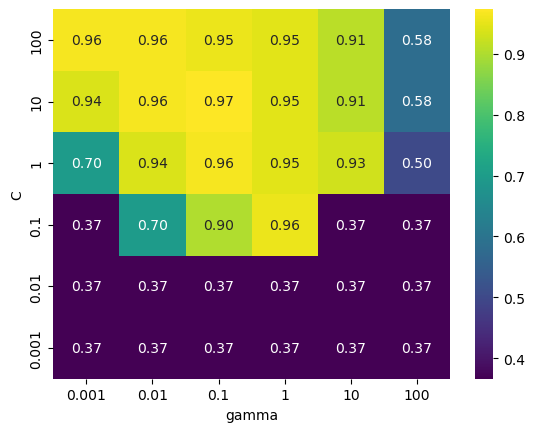

In [30]:
import seaborn as sns

sns.heatmap(
    scores,
    annot=True,
    fmt=".2f",
    xticklabels=param_grid["gamma"],
    yticklabels=param_grid["C"],
    cmap="viridis",
)
plt.xlabel("gamma")
plt.ylabel("C")
plt.gca().invert_yaxis()
plt.show()

In [31]:
param_grid = [
    {
        'kernel': ['rbf'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        "gamma": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        'kernel': ['linear'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100]
    }
]

In [34]:
gs = GridSearchCV(SVC(), param_grid=param_grid, cv=10, n_jobs=-1)
gs.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"[{'C': [0.001, 0.01, ...], 'gamma': [0.001, 0.01, ...], 'kernel': ['rbf']}, {'C': [0.001, 0.01, ...], 'kernel': ['linear']}]"
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [35]:
gs.best_params_

{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

In [36]:
gs.best_score_

np.float64(0.9818181818181818)

In [37]:
gs.score(X_test, y_test)

0.9736842105263158

In [41]:
results = pd.DataFrame(gs.cv_results_)
results.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41
mean_fit_time,0.001722,0.00123,0.000666,0.000694,0.000633,0.000644,0.000617,0.000683,0.000607,0.000609,0.000779,0.000684,0.000923,0.000596,0.000501,0.0005,0.000617,0.001331,0.000635,0.000615,0.000402,0.000448,0.000651,0.000669,0.000581,0.00033,0.000463,0.000414,0.000739,0.00067,0.000345,0.000378,0.00035,0.000799,0.000684,0.000843,0.000683,0.000436,0.00066,0.000332,0.000387,0.000407
std_fit_time,0.001352,0.001004,0.000161,0.000088,0.000063,0.000073,0.000066,0.000123,0.000059,0.000047,0.000389,0.000073,0.000584,0.000046,0.000071,0.000054,0.000065,0.00088,0.000087,0.000388,0.0001,0.000099,0.000012,0.000025,0.000315,0.00003,0.000228,0.00007,0.000126,0.00004,0.000056,0.000201,0.000063,0.000925,0.000063,0.000341,0.000259,0.000016,0.000436,0.000059,0.000187,0.000095
mean_score_time,0.000529,0.000374,0.000326,0.000291,0.00033,0.000266,0.000271,0.000332,0.000254,0.00032,0.000262,0.000281,0.000363,0.000273,0.000251,0.000217,0.000277,0.000534,0.000322,0.000246,0.000225,0.000216,0.000289,0.00023,0.00029,0.000195,0.000288,0.00021,0.000281,0.000248,0.000202,0.000261,0.000219,0.000521,0.000272,0.000312,0.000291,0.000193,0.000435,0.000213,0.000197,0.000244
std_score_time,0.00021,0.000169,0.000193,0.000046,0.000119,0.000028,0.000045,0.000122,0.000021,0.000157,0.000046,0.000036,0.000288,0.000051,0.000049,0.000012,0.000122,0.000709,0.000143,0.000043,0.000053,0.000018,0.000187,0.000012,0.000147,0.000015,0.000187,0.000027,0.000078,0.000019,0.000015,0.000208,0.000046,0.000646,0.000091,0.000198,0.000155,0.000007,0.000228,0.000048,0.000025,0.000114
param_C,0.001,0.001,0.001,0.001,0.001,0.001,0.01,0.01,0.01,0.01,0.01,0.01,0.1,0.1,0.1,0.1,0.1,0.1,1.0,1.0,1.0,1.0,1.0,1.0,10.0,10.0,10.0,10.0,10.0,10.0,100.0,100.0,100.0,100.0,100.0,100.0,0.001,0.01,0.1,1.0,10.0,100.0
param_gamma,0.001,0.01,0.1,1.0,10.0,100.0,0.001,0.01,0.1,1.0,10.0,100.0,0.001,0.01,0.1,1.0,10.0,100.0,0.001,0.01,0.1,1.0,10.0,100.0,0.001,0.01,0.1,1.0,10.0,100.0,0.001,0.01,0.1,1.0,10.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN
param_kernel,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,linear,linear,linear,linear,linear,linear
params,"{'C': 0.001, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 1, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 10, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 1, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 10, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 10, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 100, 'kernel': 'rbf'}","{'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 1, 'gamma': 1, 'kernel': 'rbf'}","{'C': 1, 'gamma': 10, 'kernel': 'rbf'}","{'C': 1, 'gamma': 100, 'kernel': 'rbf'}","{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 10, 'gamma': 1, 'kernel': 'rbf'}","{'C': 10, 'gamma': 10, 'kernel': 'rbf'}","{'C': 10, 'gamma': 100, 'kernel': 'rbf'}","{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 100, 'gamma': 1, 'kernel': 'rbf'}","{'C': 100, 'gamma': 10, 'kernel': 'rbf'}","{'C': 100, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.001, 'kernel': 'linear'}","{'C': 0.01, 'kernel': 'linear'}","{'C': 0.1, 'kernel': 'linear'}","{'C':

In [52]:
scores = cross_val_score(
    GridSearchCV(SVC(), param_grid=param_grid, cv=10, n_jobs=-1), iris.data, iris.target, cv=10, n_jobs=-1
)

scores

array([1.        , 0.93333333, 1.        , 1.        , 0.86666667, 1.        ,
       0.93333333, 1.        , 1.        , 1.        ])

In [53]:
scores.mean()

np.float64(0.9733333333333334)